# **CASE STUDY 3: Brain Tumor Detection + CAM**

Folders: ['.config', 'yes', 'no', 'drive', 'brain_tumor_dataset', 'braintumor dataset.zip', 'sample_data']
Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5271 - loss: 0.8041 - val_accuracy: 0.7400 - val_loss: 0.5997
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7882 - loss: 0.5305 - val_accuracy: 0.5600 - val_loss: 0.8744
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 957ms/step - accuracy: 0.7586 - loss: 0.5705 - val_accuracy: 0.6800 - val_loss: 0.5557
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7537 - loss: 0.5081 - val_accuracy: 0.7400 - val_loss: 0.5492
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 953ms/step - accuracy: 0.8128 - loss: 0.4580 - val_accuracy: 0.7600 - val_loss: 0.5445
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.7600 - loss: 0.5445
Validation Accuracy: 0.7599999904632568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Prediction: Tumor


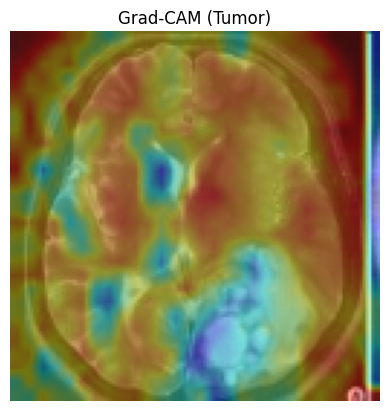

array([[[136,   0,   0],
        [136,   0,   0],
        [136,   0,   0],
        ...,
        [  0,  80, 255],
        [  0,  36, 255],
        [  0,  36, 255]],

       [[136,   0,   0],
        [136,   0,   0],
        [136,   0,   0],
        ...,
        [  0,  80, 255],
        [  0,  36, 255],
        [  0,  36, 255]],

       [[136,   0,   0],
        [136,   0,   0],
        [136,   0,   0],
        ...,
        [  0,  76, 255],
        [  0,  36, 255],
        [  0,  36, 255]],

       ...,

       [[ 98, 255, 158],
        [ 98, 255, 158],
        [ 98, 255, 158],
        ...,
        [236,   0,   0],
        [240,   0,   0],
        [240,   0,   0]],

       [[ 98, 255, 158],
        [ 98, 255, 158],
        [ 98, 255, 158],
        ...,
        [208,   0,   0],
        [208,   0,   0],
        [208,   0,   0]],

       [[ 98, 255, 158],
        [ 98, 255, 158],
        [ 98, 255, 158],
        ...,
        [208,   0,   0],
        [208,   0,   0],
        [208,   0,   0]]], dtype=uint8)
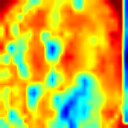

In [12]:
# ============================
# Brain Tumor Detection + Grad-CAM (FINAL WORKING CODE)
# ============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import zipfile
import os
from tensorflow.keras import layers, models

# ----------------------------
# 1. Unzip Dataset from Drive
# ----------------------------
zip_path = "/content/drive/MyDrive/braintumor dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Folders:", os.listdir("/content"))

# ----------------------------
# 2. Dataset Path
# ----------------------------
data_path = "/content/brain_tumor_dataset"   # already confirmed from your output

# ----------------------------
# 3. Load Dataset
# ----------------------------
img_size = 128
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

# ----------------------------
# 4. Normalize
# ----------------------------
normalization_layer = layers.Rescaling(1./255)
train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

# ----------------------------
# 5. CNN Model
# ----------------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', name="last_conv"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# ----------------------------
# 6. Compile & Train
# ----------------------------
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(train_data, validation_data=val_data, epochs=5)

# ----------------------------
# 7. Evaluate
# ----------------------------
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

# ----------------------------
# 8. Grad-CAM Function
# ----------------------------
def get_gradcam(img_array, model):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer("last_conv").output, model.outputs[0]]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

# ----------------------------
# 9. Take Sample Image
# ----------------------------
for images, labels in val_data.take(1):
    sample = images[0:1]
    break

# 🔥 IMPORTANT FIX (build model graph)
model(tf.zeros((1, 128, 128, 3)))

# Prediction
pred = model.predict(sample)[0][0]
label = "Tumor" if pred > 0.5 else "No Tumor"
print("Prediction:", label)

# ----------------------------
# 10. Grad-CAM Visualization
# ----------------------------
heatmap = get_gradcam(sample, model)

img = (sample[0].numpy() * 255).astype(np.uint8)
img = cv2.resize(img, (128,128))

heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.imshow(superimposed_img)
plt.title(f"Grad-CAM ({label})")
plt.axis('off')
plt.show()

heatmap


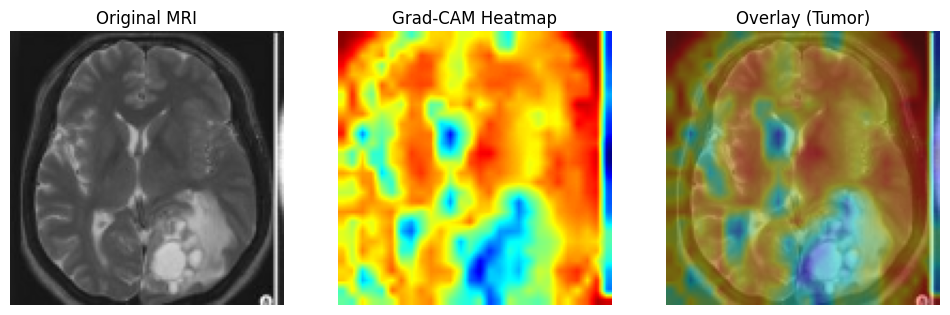

In [13]:
# ----------------------------
# Show Original vs Heatmap vs Overlay
# ----------------------------

plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(sample[0])
plt.title("Original MRI")
plt.axis('off')

# Heatmap
plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis('off')

# Overlay
plt.subplot(1,3,3)
plt.imshow(superimposed_img)
plt.title(f"Overlay ({label})")
plt.axis('off')

plt.show()